In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt  
file_path = "C:\\Users\\NEO\\Desktop\\ODLDATASET\\diabetes_binary_5050split_health_indicators_BRFSS2015.csv"
df = pd.read_csv(file_path)


In [11]:
print("Shape:", df.shape)
df.head()


Shape: (70692, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [12]:
print("Columns:")
for col in df.columns:
    print("-", col)

Columns:
- Diabetes_binary
- HighBP
- HighChol
- CholCheck
- BMI
- Smoker
- Stroke
- HeartDiseaseorAttack
- PhysActivity
- Fruits
- Veggies
- HvyAlcoholConsump
- AnyHealthcare
- NoDocbcCost
- GenHlth
- MentHlth
- PhysHlth
- DiffWalk
- Sex
- Age
- Education
- Income


In [13]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentHlth           

In [14]:
df.nunique()

Diabetes_binary          2
HighBP                   2
HighChol                 2
CholCheck                2
BMI                     80
Smoker                   2
Stroke                   2
HeartDiseaseorAttack     2
PhysActivity             2
Fruits                   2
Veggies                  2
HvyAlcoholConsump        2
AnyHealthcare            2
NoDocbcCost              2
GenHlth                  5
MentHlth                31
PhysHlth                31
DiffWalk                 2
Sex                      2
Age                     13
Education                6
Income                   8
dtype: int64

In [15]:
duplicate_rows = df[df.duplicated()]
print(f"Duplicate Rows: {duplicate_rows.shape[0]}")




Duplicate Rows: 1635


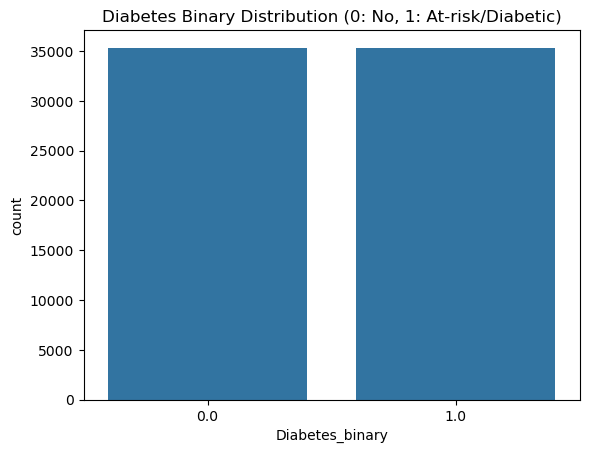

In [15]:
df['Diabetes_binary'].value_counts()


sns.countplot(data=df, x='Diabetes_binary')
plt.title("Diabetes Binary Distribution (0: No, 1: At-risk/Diabetic)")
plt.show()


Categorical/Binary variables (18): ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
Continuous variables (3): ['BMI', 'MentHlth', 'PhysHlth']


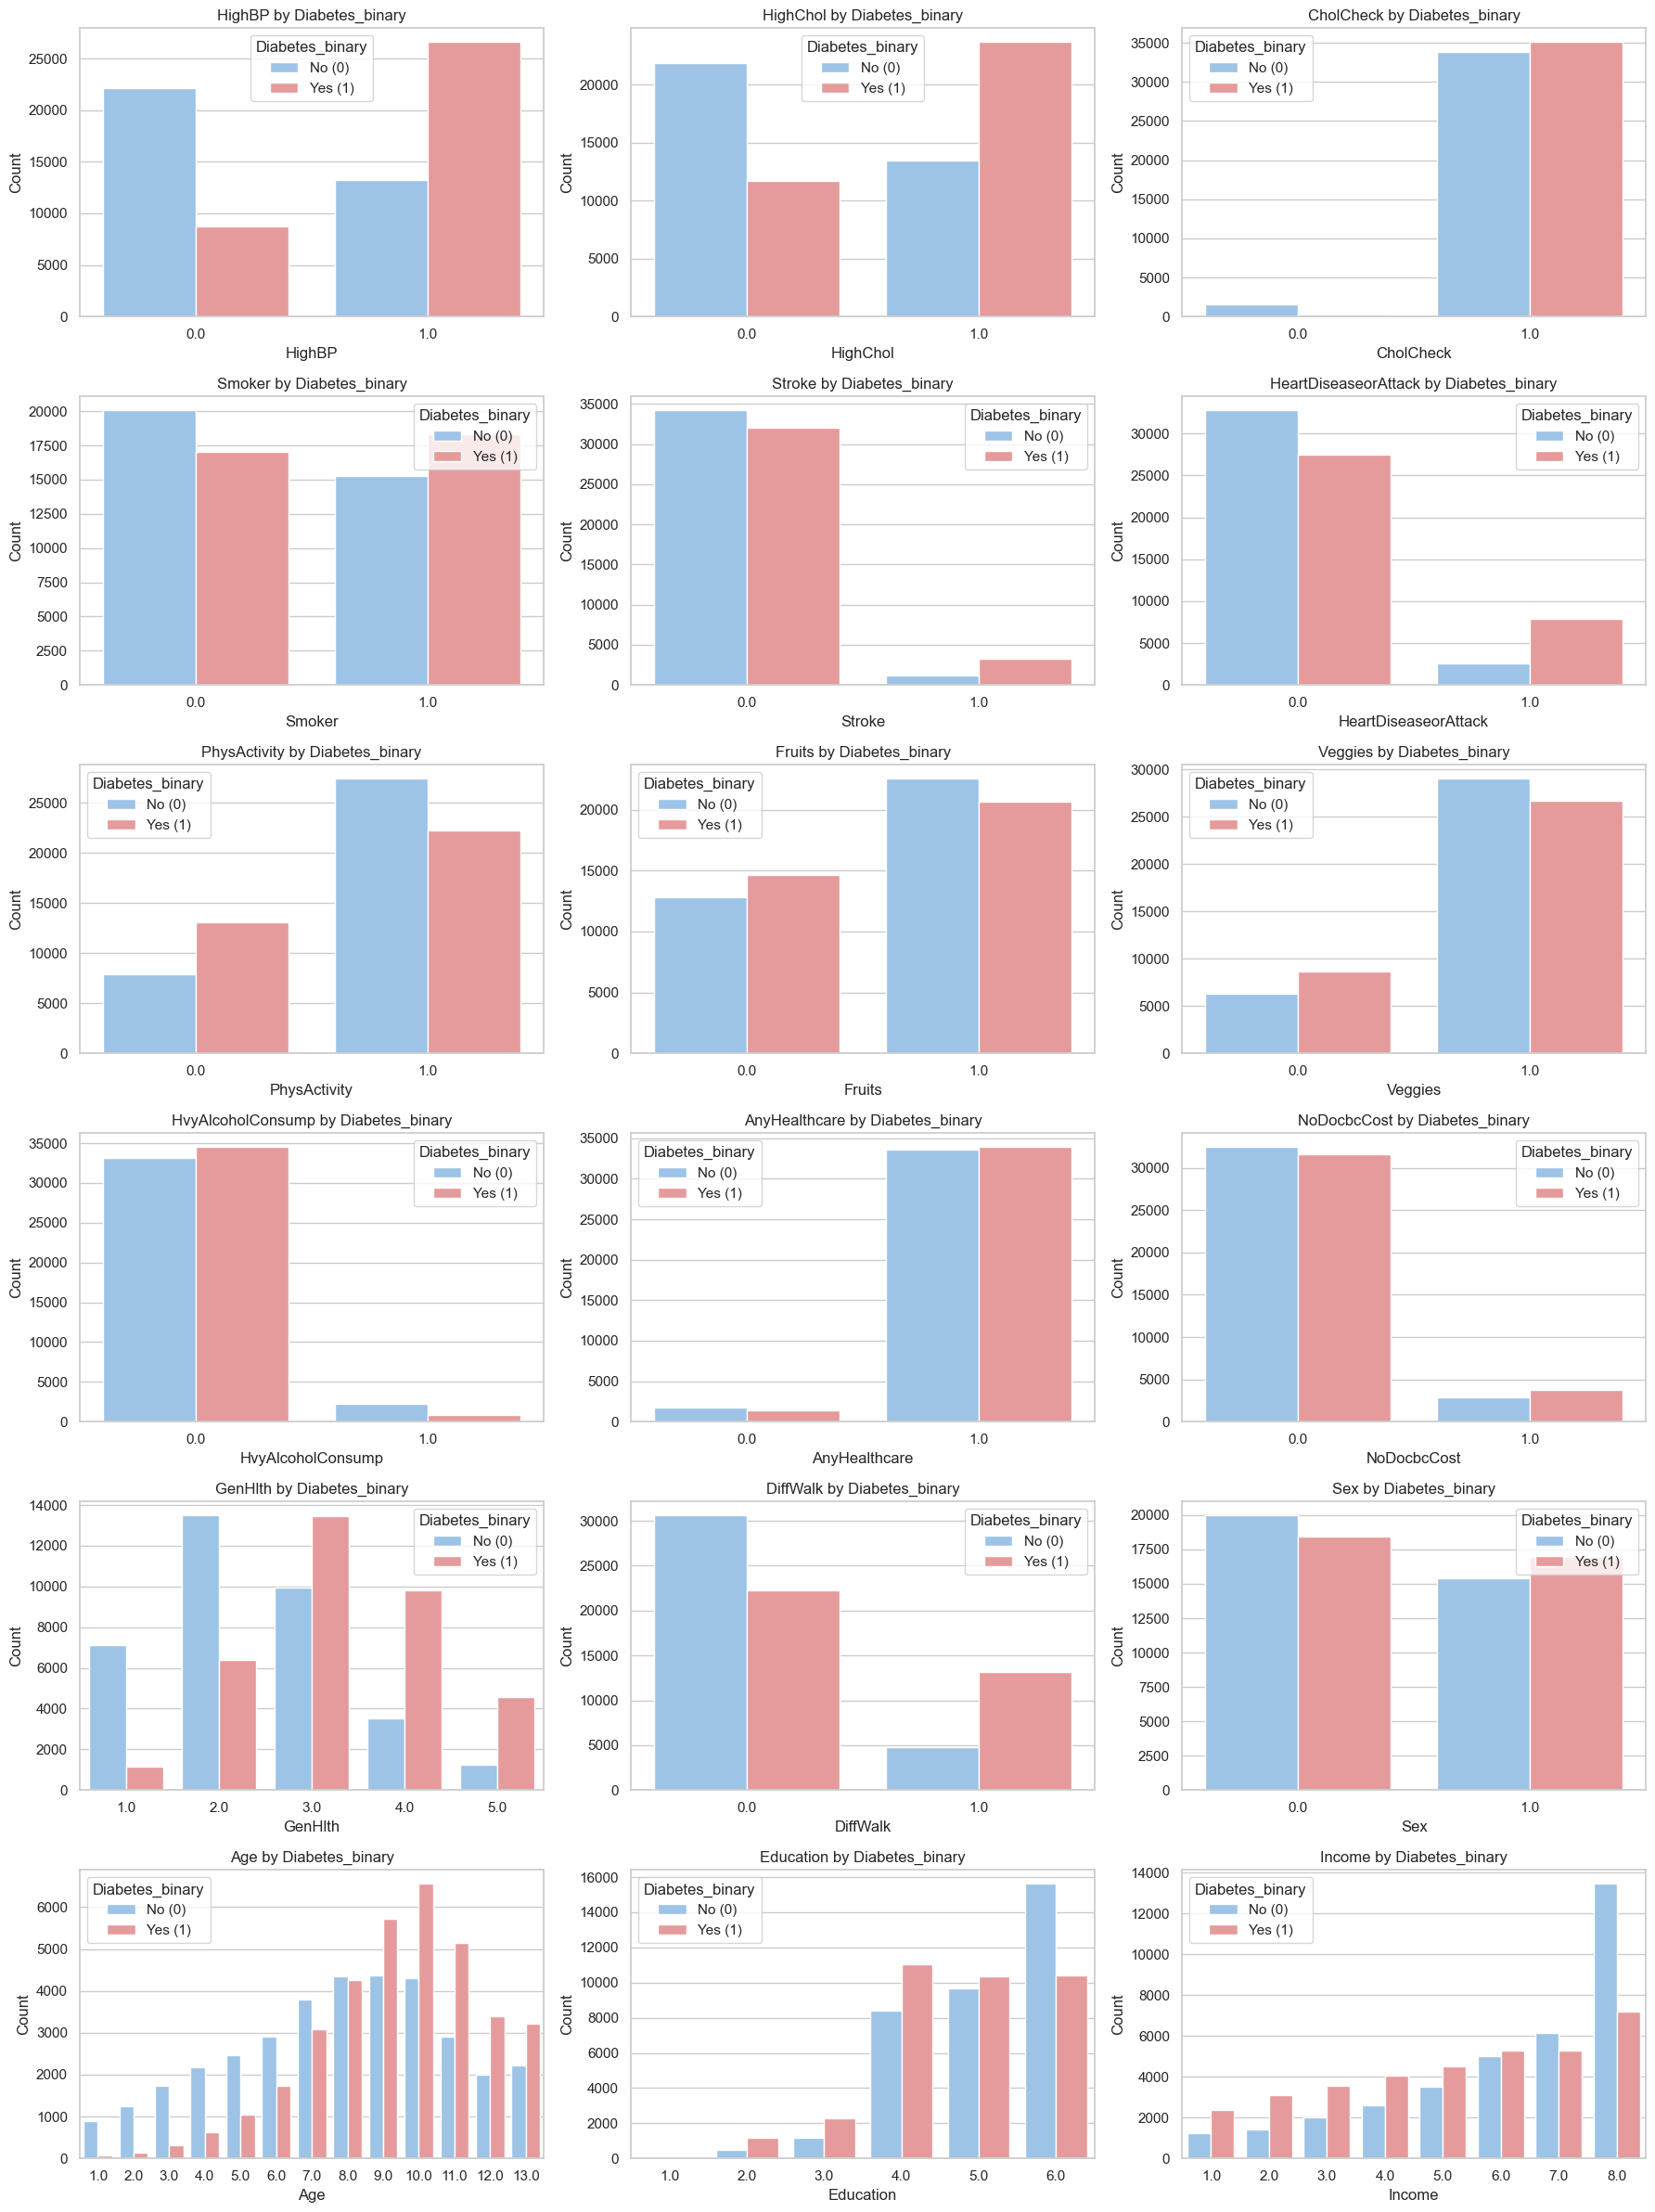

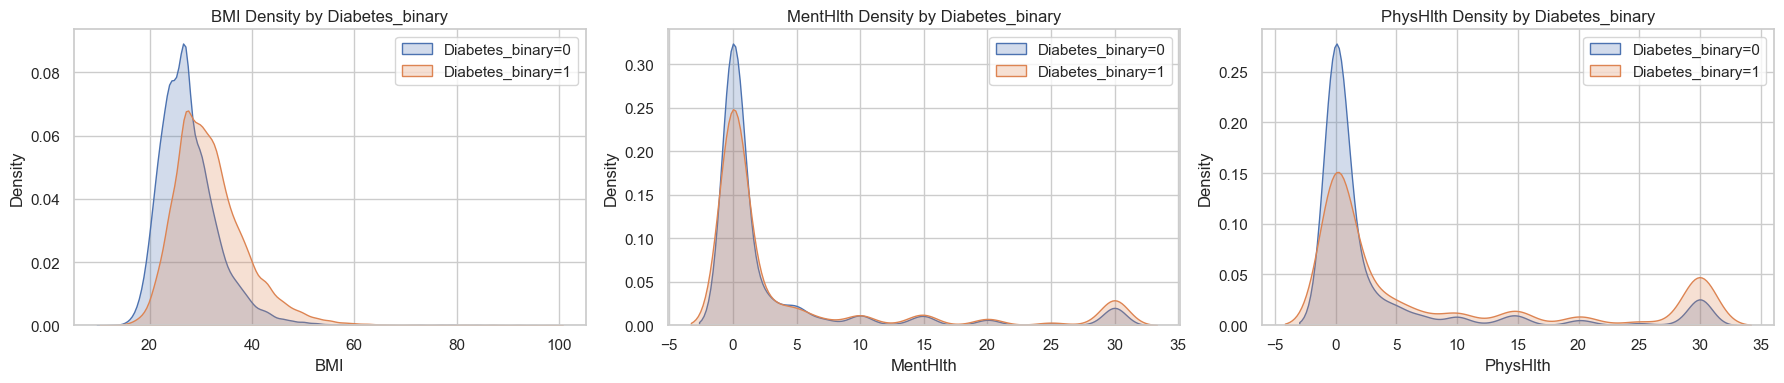

In [17]:
import os, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  

TARGET = 'Diabetes_binary'
assert TARGET in df.columns, f"Target column {TARGET} is not in the dataset"

forced_categorical = {'GenHlth', 'Age', 'Education', 'Income'}
cat_threshold = 10

features = [c for c in df.columns if c != TARGET]

categorical_cols, continuous_cols = [], []
for c in features:
    nunique = df[c].nunique(dropna=True)
    if (nunique <= cat_threshold) or (c in forced_categorical):
        categorical_cols.append(c)
    else:
        continuous_cols.append(c)

print(f"Categorical/Binary variables ({len(categorical_cols)}): {categorical_cols}")
print(f"Continuous variables ({len(continuous_cols)}): {continuous_cols}")

#  Set color palette & style 
custom_palette = {0: "#91c4f2", 1: "#f28e8e"}  # 0 = Non-diabetic, 1 = Diabetic/Pre-diabetic
sns.set(style="whitegrid")

def _grid(n_items, n_cols=3):
    n_rows = math.ceil(n_items / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
    axes = np.atleast_1d(axes).flatten()
    return fig, axes

def _hide_unused(axes, used):
    for j in range(used, len(axes)):
        axes[j].axis("off")

def plot_categoricals(data, cols, target=TARGET, n_cols=3, save=False, outdir="eda_plots"):
    if not cols: 
        return
    fig, axes = _grid(len(cols), n_cols)
    for i, col in enumerate(cols):
        ax = axes[i]
        sns.countplot(data=data, x=col, hue=target, palette=custom_palette, ax=ax)
        ax.set_title(f"{col} by {target}")
        ax.set_xlabel(col); ax.set_ylabel("Count")
        # Show legend with clearer labels
        ax.legend(title=target, labels=["No (0)", "Yes (1)"])
    _hide_unused(axes, len(cols))
    plt.tight_layout()
    if save:
        os.makedirs(outdir, exist_ok=True)
        plt.savefig(os.path.join(outdir, "categorical_vs_target.png"), dpi=160, bbox_inches="tight")
    plt.show()

def plot_continuous_kde(data, cols, target=TARGET, n_cols=3, save=False, outdir="eda_plots"):
    if not cols: 
        return
    fig, axes = _grid(len(cols), n_cols)
    for i, col in enumerate(cols):
        ax = axes[i]
        # Plot KDE for each class
        for cls in (0, 1):
            subset = data[data[target] == cls][col].dropna()
            if subset.nunique() > 1:  # Prevent errors if only a single unique value
                sns.kdeplot(subset, fill=True, ax=ax, label=f"{target}={cls}")
        ax.set_title(f"{col} Density by {target}")
        ax.set_xlabel(col); ax.set_ylabel("Density")
        ax.legend()
    _hide_unused(axes, len(cols))
    plt.tight_layout()
    if save:
        os.makedirs(outdir, exist_ok=True)
        plt.savefig(os.path.join(outdir, "continuous_kde_vs_target.png"), dpi=160, bbox_inches="tight")
    plt.show()

def plot_continuous_box(data, cols, target=TARGET, n_cols=3, save=False, outdir="eda_plots"):
    if not cols: 
        return
    fig, axes = _grid(len(cols), n_cols)
    for i, col in enumerate(cols):
        ax = axes[i]
        sns.boxplot(data=data, x=target, y=col, palette=custom_palette, ax=ax)
        ax.set_title(f"{col} vs {target} (Box)")
        ax.set_xlabel(target); ax.set_ylabel(col)
        ax.set_xticklabels(["0", "1"])
    _hide_unused(axes, len(cols))
    plt.tight_layout()
    if save:
        os.makedirs(outdir, exist_ok=True)
        plt.savefig(os.path.join(outdir, "continuous_box_vs_target.png"), dpi=160, bbox_inches="tight")
    plt.show()
plot_categoricals(df, categorical_cols, save=True)     
plot_continuous_kde(df, continuous_cols, save=True)    



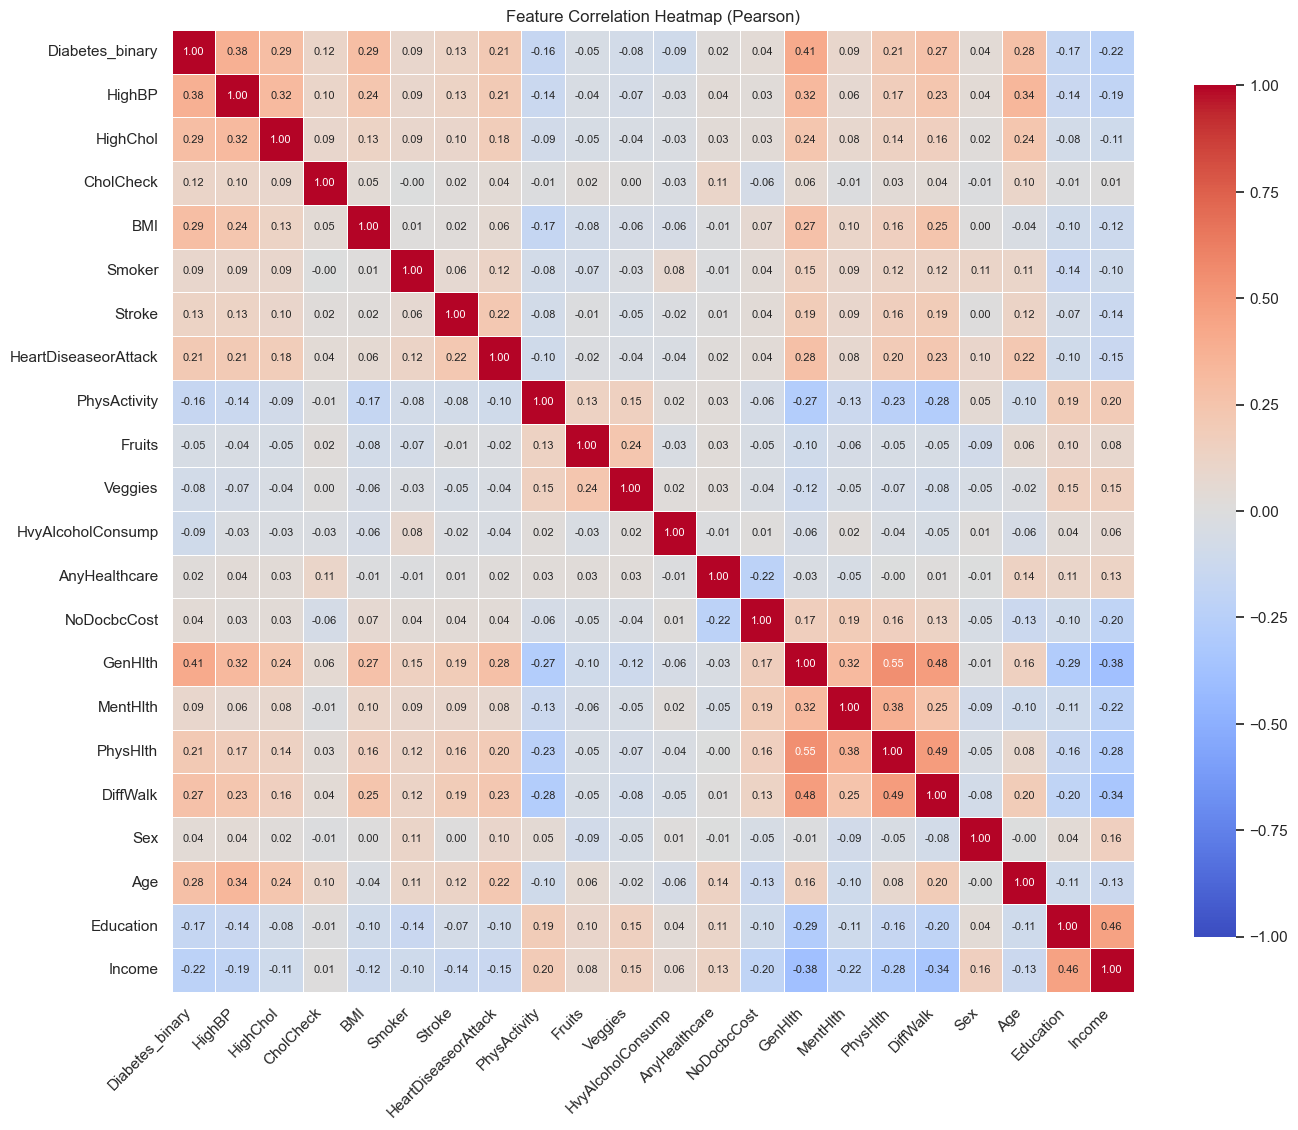

In [ ]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(14,12))
ax = sns.heatmap(
    corr,
    annot=True,          
    fmt=".2f",            
    cmap="coolwarm",
    vmin=-1, vmax=1, center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size":8}  
)
plt.title("Feature Correlation Heatmap (Pearson)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



####Preprocessing

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path
import joblib

FILE = r"C:\Users\NEO\Desktop\ODLDATASET\diabetes_binary_5050split_health_indicators_BRFSS2015.csv"
df = pd.read_csv(FILE)

print("Before drop_duplicates:", df.shape)
df = df.drop_duplicates().reset_index(drop=True)
print("After drop_duplicates:", df.shape)


TARGET = "Diabetes_binary"
features = [c for c in df.columns if c != TARGET]


continuous_cols = ["BMI", "MentHlth", "PhysHlth"]
ordinal_cols    = ["GenHlth", "Age", "Education", "Income"]
binary_cols     = [c for c in features if c not in continuous_cols + ordinal_cols]

print("Binary cols    :", binary_cols)
print("Ordinal cols   :", ordinal_cols)
print("Continuous cols:", continuous_cols)


df["BMI"]      = df["BMI"].clip(lower=10, upper=60)
df["MentHlth"] = df["MentHlth"].clip(lower=0,  upper=30)
df["PhysHlth"] = df["PhysHlth"].clip(lower=0,  upper=30)

X = df[features].copy()
y = df[TARGET].astype(int).copy()


X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train/Val/Test shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Class balance (train):", np.bincount(y_train))

scaler = MinMaxScaler()
X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_test_scaled  = X_test.copy()


cols_to_scale = continuous_cols + ordinal_cols  
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_val_scaled[cols_to_scale]   = scaler.transform(X_val[cols_to_scale])
X_test_scaled[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])


X_train_mlp = X_train_scaled.values.astype(np.float32)
X_val_mlp   = X_val_scaled.values.astype(np.float32)
X_test_mlp  = X_test_scaled.values.astype(np.float32)


X_train_lstm = X_train_mlp.reshape(len(X_train_mlp), 1, X_train_mlp.shape[1])
X_val_lstm   = X_val_mlp.reshape(len(X_val_mlp), 1, X_val_mlp.shape[1])
X_test_lstm  = X_test_mlp.reshape(len(X_test_mlp), 1, X_test_mlp.shape[1])

y_train = y_train.values.astype(np.int64)
y_val   = y_val.values.astype(np.int64)
y_test  = y_test.values.astype(np.int64)

print("MLP shapes :", X_train_mlp.shape, X_val_mlp.shape, X_test_mlp.shape)
print("LSTM shapes:", X_train_lstm.shape, X_val_lstm.shape, X_test_lstm.shape)


outdir = Path("./preprocessed")
outdir.mkdir(parents=True, exist_ok=True)

np.save(outdir / "X_train_mlp.npy", X_train_mlp)
np.save(outdir / "X_val_mlp.npy",   X_val_mlp)
np.save(outdir / "X_test_mlp.npy",  X_test_mlp)

np.save(outdir / "X_train_lstm.npy", X_train_lstm)
np.save(outdir / "X_val_lstm.npy",   X_val_lstm)
np.save(outdir / "X_test_lstm.npy",  X_test_lstm)

np.save(outdir / "y_train.npy", y_train)
np.save(outdir / "y_val.npy",   y_val)
np.save(outdir / "y_test.npy",  y_test)

joblib.dump(scaler, outdir / "minmax_scaler.joblib")
print("Saved to:", outdir.resolve())


Before drop_duplicates: (70692, 22)
After drop_duplicates: (69057, 22)
Binary cols    : ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']
Ordinal cols   : ['GenHlth', 'Age', 'Education', 'Income']
Continuous cols: ['BMI', 'MentHlth', 'PhysHlth']
Train/Val/Test shapes: (48339, 21) (10359, 21) (10359, 21)
Class balance (train): [23772 24567]
MLP shapes : (48339, 21) (10359, 21) (10359, 21)
LSTM shapes: (48339, 1, 21) (10359, 1, 21) (10359, 1, 21)
Saved to: C:\Users\NEO\Desktop\preprocessed


###build modeling

In [22]:
import os, random
import numpy as np
import tensorflow as tf
from pathlib import Path


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


DATA_DIR = Path("./preprocessed")  
X_train_mlp = np.load(DATA_DIR / "X_train_mlp.npy")
X_val_mlp   = np.load(DATA_DIR / "X_val_mlp.npy")
X_test_mlp  = np.load(DATA_DIR / "X_test_mlp.npy")

X_train_lstm = np.load(DATA_DIR / "X_train_lstm.npy")
X_val_lstm   = np.load(DATA_DIR / "X_val_lstm.npy")
X_test_lstm  = np.load(DATA_DIR / "X_test_lstm.npy")

y_train = np.load(DATA_DIR / "y_train.npy")
y_val   = np.load(DATA_DIR / "y_val.npy")
y_test  = np.load(DATA_DIR / "y_test.npy")

X_train_mlp.shape, X_val_mlp.shape, X_test_mlp.shape, X_train_lstm.shape



((48339, 21), (10359, 21), (10359, 21), (48339, 1, 21))

In [23]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, classification_report

def evaluate_binary_clf(y_true, y_prob, threshold=0.5, name="Model"):
    y_pred = (y_prob >= threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    f1  = f1_score(y_true, y_pred)
    cm  = confusion_matrix(y_true, y_pred)
    print(f"[{name}] Acc={acc:.4f} | ROC-AUC={auc:.4f} | F1={f1:.4f}")
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_true, y_pred, digits=4))
    return {"acc": acc, "auc": auc, "f1": f1, "cm": cm}


###mlp

In [24]:
from pathlib import Path
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

def build_mlp(input_dim: int) -> keras.Model:
    inputs = keras.Input(shape=(input_dim,))
    x = layers.Dense(128, activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.30)(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.20)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs, name="MLP_Baseline")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")]
    )
    return model

mlp = build_mlp(X_train_mlp.shape[1])
mlp.summary()

ckpt_dir = Path("./checkpoints"); ckpt_dir.mkdir(exist_ok=True)
mlp_ckpt_path = str(ckpt_dir / "mlp_best.keras")

cbs = [
    callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=8, restore_best_weights=True),
    callbacks.ModelCheckpoint(mlp_ckpt_path, monitor="val_auc", mode="max", save_best_only=True),
    callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", patience=4, factor=0.5, min_lr=1e-5),
]

history_mlp = mlp.fit(
    X_train_mlp, y_train,
    validation_data=(X_val_mlp, y_val),
    epochs=60,
    batch_size=512,
    callbacks=cbs,
    verbose=1
)

y_val_prob  = mlp.predict(X_val_mlp,  batch_size=1024).ravel()
y_test_prob = mlp.predict(X_test_mlp, batch_size=1024).ravel()

def evaluate_binary_clf(y_true, y_prob, name="Eval", thr=0.5):
    y_pred = (y_prob >= thr).astype(int)
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    cm  = confusion_matrix(y_true, y_pred)
    print(f"[{name}] thr={thr:.2f} | Acc={acc:.4f} | F1={f1:.4f} | AUC={auc:.4f}")
    print("Confusion Matrix:\n", cm)
    return {"acc": acc, "f1": f1, "auc": auc, "cm": cm}

print("\n--- MLP Validation ---")
mlp_val_metrics  = evaluate_binary_clf(y_val,  y_val_prob,  name="MLP (Val)",  thr=0.5)

print("\n--- MLP Test ---")
mlp_test_metrics = evaluate_binary_clf(y_test, y_test_prob, name="MLP (Test)", thr=0.5)




Model: "MLP_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_35 (InputLayer)     │ (None, 21)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_109 (Dense)               │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_64          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_84 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_110 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_65          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_85 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_111 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,905 (46.50 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6794 - auc: 0.7383 - loss: 0.6407 - val_accuracy: 0.5638 - val_auc: 0.8069 - val_loss: 0.6565 - learning_rate: 0.0010
Epoch 2/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7239 - auc: 0.7942 - loss: 0.5504 - val_accuracy: 0.6473 - val_auc: 0.8145 - val_loss: 0.6175 - learning_rate: 0.0010
Epoch 3/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7354 - auc: 0.8080 - loss: 0.5313 - val_accuracy: 0.7044 - val_auc: 0.8165 - val_loss: 0.5697 - learning_rate: 0.0010
Epoch 4/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7397 - auc: 0.8120 - loss: 0.5248 - val_accuracy: 0.7307 - val_auc: 0.8191 - val_loss: 0.5372 - learning_rate: 0.0010
Epoch 5/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7413 - auc: 0.8146 - loss: 0.5217 - val_accuracy: 0.7389 - val_auc: 0.8197 - val_loss: 0.5234 - learning_rate: 0.0010
Epoch 6/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7429 - auc: 0.8173 - loss:

###lstm

In [ ]:
def build_lstm(input_shape) -> keras.Model:
    inputs = keras.Input(shape=input_shape)  
    x = layers.LSTM(64, return_sequences=False)(inputs)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs, name="LSTM_Baseline")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")]
    )
    return model
lstm = build_lstm(X_train_lstm.shape[1:])
lstm.summary()

lstm_ckpt_path = str(ckpt_dir / "lstm_best.keras")
cbs_lstm = [
    callbacks.EarlyStopping(monitor="val_auc", patience=8, mode="max", restore_best_weights=True),
    callbacks.ModelCheckpoint(lstm_ckpt_path, monitor="val_auc", mode="max", save_best_only=True),
    callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", patience=4, factor=0.5, min_lr=1e-5)
]

history_lstm = lstm.fit(
    X_train_lstm, y_train,
    validation_data=(X_val_lstm, y_val),
    epochs=60,
    batch_size=512,
    callbacks=cbs_lstm,
    verbose=1
)
y_val_prob_lstm  = lstm.predict(X_val_lstm, batch_size=1024).ravel()
y_test_prob_lstm = lstm.predict(X_test_lstm, batch_size=1024).ravel()
print("\n--- LSTM Validation ---")
lstm_val_metrics = evaluate_binary_clf(y_val, y_val_prob_lstm, name="LSTM (Val)")
print("\n--- LSTM Test ---")
lstm_test_metrics = evaluate_binary_clf(y_test, y_test_prob_lstm, name="LSTM (Test)")


Model: "LSTM_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 3, 7)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,545 (80.25 KB)

 Trainable params: 20,545 (80.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6531 - auc: 0.7110 - loss: 0.6354 - val_accuracy: 0.7315 - val_auc: 0.7999 - val_loss: 0.5387 - learning_rate: 0.0010
Epoch 2/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7359 - auc: 0.8020 - loss: 0.5364 - val_accuracy: 0.7422 - val_auc: 0.8129 - val_loss: 0.5223 - learning_rate: 0.0010
Epoch 3/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7438 - auc: 0.8131 - loss: 0.5230 - val_accuracy: 0.7453 - val_auc: 0.8160 - val_loss: 0.5184 - learning_rate: 0.0010
Epoch 4/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7453 - auc: 0.8167 - loss: 0.5194 - val_accuracy: 0.7450 - val_auc: 0.8177 - val_loss: 0.5163 - learning_rate: 0.0010
Epoch 5/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7451 - auc: 0.8189 - loss: 0.5172 - val_accuracy: 0.7453 - val_auc: 0.8187 - val_loss: 0.5148 - learning_rate: 0.0010
Epoch 6/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7474 - auc: 0.8209 - loss:

###tuning

In [ ]:
# ==== MLP Hyperparameter Tuning (Random Search, standalone cell) ====
import os, random
import numpy as np
from pathlib import Path
from pprint import pprint

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

# -------------------- Repro & paths --------------------
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

DATA_DIR = Path("./preprocessed")
X_train = np.load(DATA_DIR / "X_train_mlp.npy")
X_val   = np.load(DATA_DIR / "X_val_mlp.npy")
X_test  = np.load(DATA_DIR / "X_test_mlp.npy")
y_train = np.load(DATA_DIR / "y_train.npy")
y_val   = np.load(DATA_DIR / "y_val.npy")
y_test  = np.load(DATA_DIR / "y_test.npy")

print("MLP arrays:", X_train.shape, X_val.shape, X_test.shape)

# -------------------- Utils --------------------
def search_best_threshold(y_true, y_prob, mode="f1", lo=0.2, hi=0.8, steps=241):
    grid = np.linspace(lo, hi, steps)
    if mode == "f1":
        scores = [f1_score(y_true, (y_prob >= t).astype(int)) for t in grid]
        best_idx = int(np.argmax(scores))
        return float(grid[best_idx])
    elif mode == "acc":
        scores = [accuracy_score(y_true, (y_prob >= t).astype(int)) for t in grid]
        best_idx = int(np.argmax(scores))
        return float(grid[best_idx])
    else:  # Youden's J
        fpr, tpr, thr = roc_curve(y_true, y_prob)
        return float(thr[np.argmax(tpr - fpr)])

def evaluate_split(name, y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    cm  = confusion_matrix(y_true, y_pred)
    print(f"\n[{name}] thr={thr:.3f} | Acc={acc:.4f} | F1={f1:.4f} | AUC={auc:.4f}")
    print("Confusion Matrix:\n", cm)
    print(classification_report(y_true, y_pred, digits=4))
    return {"acc":acc, "f1":f1, "auc":auc, "cm":cm}

# -------------------- MLP builders --------------------
def build_mlp_from_hp(input_dim, hp):
    reg = regularizers.l2(hp["l2"])
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(hp["units1"], use_bias=False, kernel_regularizer=reg)(inp)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x); x = layers.Dropout(hp["drop1"])(x)

    x = layers.Dense(hp["units2"], use_bias=False, kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x); x = layers.Dropout(hp["drop2"])(x)

    if hp["use_third"]:
        x = layers.Dense(hp["units3"], use_bias=False, kernel_regularizer=reg)(x)
        x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x); x = layers.Dropout(hp["drop3"])(x)

    out = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inp, out, name="MLP_Tuned")
    model.compile(optimizer=keras.optimizers.Adam(hp["lr"]),
                  loss="binary_crossentropy",
                  metrics=[keras.metrics.AUC(name="auc"), "accuracy"])
    return model

def sample_hp_mlp(rng):
    return {
        "units1":    int(rng.choice([128, 256])),
        "units2":    int(rng.choice([64, 128])),
        "use_third": bool(rng.choice([0, 1])),
        "units3":    int(rng.choice([32, 64])),
        "drop1":     float(rng.uniform(0.30, 0.50)),
        "drop2":     float(rng.uniform(0.20, 0.45)),
        "drop3":     float(rng.uniform(0.10, 0.35)),
        "l2":        float(rng.choice([1e-5, 5e-5, 1e-4, 2e-4, 5e-4])),
        "lr":        float(rng.choice([5e-4, 1e-3, 2e-3])),
        "batch":     int(rng.choice([256, 512, 1024])),
    }

def random_search_mlp(X_tr, y_tr, X_va, y_va, n_trials=12, epochs=40, patience=6, seed=42):
    rng = np.random.default_rng(seed)
    best = {"score": -1, "hp": None, "model": None}
    for t in range(1, n_trials+1):
        hp = sample_hp_mlp(rng)
        model = build_mlp_from_hp(X_tr.shape[1], hp)
        cbs = [
            callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=patience,
                                    min_delta=1e-4, restore_best_weights=True),
            callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max",
                                        patience=max(2, patience//2), factor=0.5, min_lr=1e-5),
        ]
        print(f"\n[MLP] Trial {t}/{n_trials} hp="); pprint(hp)
        hist = model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                         epochs=epochs, batch_size=hp["batch"], callbacks=cbs, verbose=0)
        val_auc = max(hist.history["val_auc"])
        print(f" -> val_auc={val_auc:.4f}")
        if val_auc > best["score"]:
            best = {"score": val_auc, "hp": hp, "model": model}
    return best

# -------------------- Run search --------------------
N_TRIALS = 12   
best = random_search_mlp(X_train, y_train, X_val, y_val, n_trials=N_TRIALS, epochs=40, patience=6, seed=SEED)
print("\nBest MLP val_auc:", round(best["score"], 4))
print("Best MLP hparams:"); pprint(best["hp"])

# -------------------- Evaluate with best --------------------
p_val  = best["model"].predict(X_val,  batch_size=1024).ravel()
p_test = best["model"].predict(X_test, batch_size=1024).ravel()

thr = search_best_threshold(y_val, p_val, mode="f1")   # 也可换 "acc" 或 "J"
eval_val  = evaluate_split("MLP Best (Val)",  y_val,  p_val,  thr)
eval_test = evaluate_split("MLP Best (Test)", y_test, p_test, thr)

print("\nSummary | Val  AUC/Acc/F1:", round(eval_val["auc"],4),  round(eval_val["acc"],4),  round(eval_val["f1"],4))
print("Summary | Test AUC/Acc/F1:", round(eval_test["auc"],4), round(eval_test["acc"],4), round(eval_test["f1"],4))


MLP arrays: (48339, 21) (10359, 21) (10359, 21)

[MLP] Trial 1/12 hp=
{'batch': 1024,
 'drop1': 0.4717195839822765,
 'drop2': 0.374342007264841,
 'drop3': 0.12354433697191239,
 'l2': 0.0001,
 'lr': 0.002,
 'units1': 128,
 'units2': 128,
 'units3': 32,
 'use_third': True}
 -> val_auc=0.8232

[MLP] Trial 2/12 hp=
{'batch': 512,
 'drop1': 0.3900771875791134,
 'drop2': 0.2926995060581453,
 'drop3': 0.33169124721215043,
 'l2': 1e-05,
 'lr': 0.002,
 'units1': 256,
 'units2': 128,
 'units3': 64,
 'use_third': True}
 -> val_auc=0.8229

[MLP] Trial 3/12 hp=
{'batch': 256,
 'drop1': 0.34544774435695536,
 'drop2': 0.3386461967539587,
 'drop3': 0.11595431402604384,
 'l2': 0.0005,
 'lr': 0.002,
 'units1': 128,
 'units2': 128,
 'units3': 32,
 'use_third': True}
 -> val_auc=0.8215

[MLP] Trial 4/12 hp=
{'batch': 256,
 'drop1': 0.4941396048789807,
 'drop2': 0.42328028033054943,
 'drop3': 0.29459587426844047,
 'l2': 5e-05,
 'lr': 0.002,
 'units1': 256,
 'units2': 64,
 'units3': 64,
 'use_third': True}


In [ ]:
import os, random
import numpy as np
from pathlib import Path
from pprint import pprint

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

DATA_DIR = Path("./preprocessed")
X_train = np.load(DATA_DIR / "X_train_lstm.npy")  # shape (N, 1, 21)
X_val   = np.load(DATA_DIR / "X_val_lstm.npy")
X_test  = np.load(DATA_DIR / "X_test_lstm.npy")
y_train = np.load(DATA_DIR / "y_train.npy")
y_val   = np.load(DATA_DIR / "y_val.npy")
y_test  = np.load(DATA_DIR / "y_test.npy")

print("LSTM arrays:", X_train.shape, X_val.shape, X_test.shape)
def search_best_threshold(y_true, y_prob, mode="f1", lo=0.2, hi=0.8, steps=241):
    grid = np.linspace(lo, hi, steps)
    if mode == "f1":
        scores = [f1_score(y_true, (y_prob >= t).astype(int)) for t in grid]
        best_idx = int(np.argmax(scores))
        return float(grid[best_idx])
    elif mode == "acc":
        scores = [accuracy_score(y_true, (y_prob >= t).astype(int)) for t in grid]
        best_idx = int(np.argmax(scores))
        return float(grid[best_idx])
    else:  # Youden's J
        fpr, tpr, thr = roc_curve(y_true, y_prob)
        return float(thr[np.argmax(tpr - fpr)])

def evaluate_split(name, y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    cm  = confusion_matrix(y_true, y_pred)
    print(f"\n[{name}] thr={thr:.3f} | Acc={acc:.4f} | F1={f1:.4f} | AUC={auc:.4f}")
    print("Confusion Matrix:\n", cm)
    print(classification_report(y_true, y_pred, digits=4))
    return {"acc":acc, "f1":f1, "auc":auc, "cm":cm}

def build_lstm_from_hp(input_shape, hp):
    inp = keras.Input(shape=input_shape)  # (1, 21)
    x = layers.LSTM(hp["units"], return_sequences=False,
                    recurrent_dropout=hp["rec_drop"])(inp)
    x = layers.Dropout(hp["drop"])(x)
    x = layers.Dense(hp["dense_units"], activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inp, out, name="LSTM_Tuned")
    model.compile(optimizer=keras.optimizers.Adam(hp["lr"]),
                  loss="binary_crossentropy",
                  metrics=[keras.metrics.AUC(name="auc"), "accuracy"])
    return model

def sample_hp_lstm(rng):
    return {
        "units":       int(rng.choice([32, 64, 128])),
        "rec_drop":    float(rng.choice([0.0, 0.1, 0.2])),
        "drop":        float(rng.uniform(0.20, 0.45)),
        "dense_units": int(rng.choice([16, 32, 64])),
        "lr":          float(rng.choice([5e-4, 1e-3, 2e-3])),
        "batch":       int(rng.choice([256, 512, 1024])),
    }

def random_search_lstm(X_tr, y_tr, X_va, y_va, input_shape, n_trials=10, epochs=40, patience=6, seed=42):
    rng = np.random.default_rng(seed)
    best = {"score": -1, "hp": None, "model": None}
    for t in range(1, n_trials+1):
        hp = sample_hp_lstm(rng)
        model = build_lstm_from_hp(input_shape, hp)
        cbs = [
            callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=patience,
                                    min_delta=1e-4, restore_best_weights=True),
            callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max",
                                        patience=max(2, patience//2), factor=0.5, min_lr=1e-5),
        ]
        print(f"\n[LSTM] Trial {t}/{n_trials} hp="); pprint(hp)
        hist = model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                         epochs=epochs, batch_size=hp["batch"], callbacks=cbs, verbose=0)
        val_auc = max(hist.history["val_auc"])
        print(f" -> val_auc={val_auc:.4f}")
        if val_auc > best["score"]:
            best = {"score": val_auc, "hp": hp, "model": model}
    return best

# -------------------- Run search --------------------
N_TRIALS = 10   
best = random_search_lstm(X_train, y_train, X_val, y_val, input_shape=X_train.shape[1:],
                          n_trials=N_TRIALS, epochs=40, patience=6, seed=SEED)
print("\nBest LSTM val_auc:", round(best["score"], 4))
print("Best LSTM hparams:"); pprint(best["hp"])

# -------------------- Evaluate with best --------------------
p_val  = best["model"].predict(X_val,  batch_size=1024).ravel()
p_test = best["model"].predict(X_test, batch_size=1024).ravel()

thr = search_best_threshold(y_val, p_val, mode="f1")   
eval_val  = evaluate_split("LSTM Best (Val)",  y_val,  p_val,  thr)
eval_test = evaluate_split("LSTM Best (Test)", y_test, p_test, thr)

print("\nSummary | Val  AUC/Acc/F1:", round(eval_val["auc"],4),  round(eval_val["acc"],4),  round(eval_val["f1"],4))
print("Summary | Test AUC/Acc/F1:", round(eval_test["auc"],4), round(eval_test["acc"],4), round(eval_test["f1"],4))


LSTM arrays: (48339, 1, 21) (10359, 1, 21) (10359, 1, 21)

[LSTM] Trial 1/10 hp=
{'batch': 256,
 'dense_units': 32,
 'drop': 0.30971960993801306,
 'lr': 0.002,
 'rec_drop': 0.2,
 'units': 32}
 -> val_auc=0.8232

[LSTM] Trial 2/10 hp=
{'batch': 1024,
 'dense_units': 16,
 'drop': 0.443905587909189,
 'lr': 0.002,
 'rec_drop': 0.0,
 'units': 128}
 -> val_auc=0.8226

[LSTM] Trial 3/10 hp=
{'batch': 512,
 'dense_units': 64,
 'drop': 0.23202840816888648,
 'lr': 0.001,
 'rec_drop': 0.2,
 'units': 128}
 -> val_auc=0.8233

[LSTM] Trial 4/10 hp=
{'batch': 1024,
 'dense_units': 64,
 'drop': 0.3609662800201662,
 'lr': 0.001,
 'rec_drop': 0.0,
 'units': 64}
 -> val_auc=0.8221

[LSTM] Trial 5/10 hp=
{'batch': 1024,
 'dense_units': 16,
 'drop': 0.25680968044619423,
 'lr': 0.001,
 'rec_drop': 0.1,
 'units': 64}
 -> val_auc=0.8215

[LSTM] Trial 6/10 hp=
{'batch': 1024,
 'dense_units': 64,
 'drop': 0.3579160997805162,
 'lr': 0.0005,
 'rec_drop': 0.2,
 'units': 32}
 -> val_auc=0.8194

[LSTM] Trial 7/10 hp

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
[Thresholds] MLP=0.430, LSTM=0.413


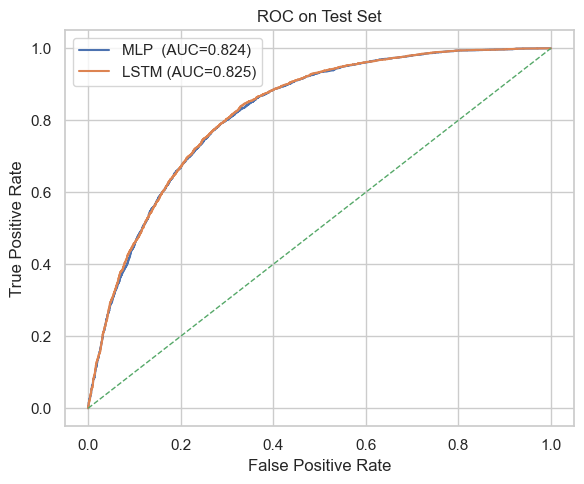

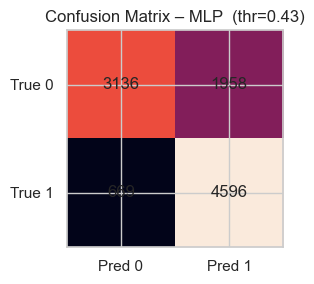

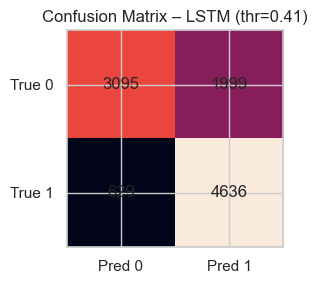

In [ ]:
import os, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_curve, auc, confusion_matrix


DATA_DIR = Path("./preprocessed")
def need(name): return (name not in globals()) or (globals()[name] is None)

if need("X_val_mlp"):   X_val_mlp   = np.load(DATA_DIR / "X_val_mlp.npy")
if need("X_test_mlp"):  X_test_mlp  = np.load(DATA_DIR / "X_test_mlp.npy")
if need("X_val_lstm"):  X_val_lstm  = np.load(DATA_DIR / "X_val_lstm.npy")
if need("X_test_lstm"): X_test_lstm = np.load(DATA_DIR / "X_test_lstm.npy")
if need("y_val"):       y_val       = np.load(DATA_DIR / "y_val.npy")
if need("y_test"):      y_test      = np.load(DATA_DIR / "y_test.npy")


from sklearn.metrics import accuracy_score, f1_score, roc_curve

def search_best_threshold(y_true, y_prob, mode="f1", lo=0.2, hi=0.8, steps=241):
    grid = np.linspace(lo, hi, steps)
    if mode == "f1":
        scores = [f1_score(y_true, (y_prob >= t).astype(int)) for t in grid]
        return float(grid[int(np.argmax(scores))])
    elif mode == "acc":
        scores = [accuracy_score(y_true, (y_prob >= t).astype(int)) for t in grid]
        return float(grid[int(np.argmax(scores))])
    else:  
        fpr, tpr, thr = roc_curve(y_true, y_prob)
        return float(thr[np.argmax(tpr - fpr)])

def plot_cm_simple(y_true, y_prob, thr, title):
    y_pred = (y_prob >= thr).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    plt.imshow(cm, interpolation='nearest')
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha='center', va='center')
    plt.xticks([0,1], ["Pred 0","Pred 1"])
    plt.yticks([0,1], ["True 0","True 1"])
    plt.title(title); plt.tight_layout(); plt.show()

from tensorflow.keras.models import load_model

def pick_mlp_model():
   
    m = None
    if "best_mlp" in globals() and isinstance(best_mlp, dict) and "model" in best_mlp:
        m = best_mlp["model"]

    if m is None and "best" in globals():
        try:
            if len(best["model"].input_shape) == 2: m = best["model"]
        except Exception: pass

    if m is None and Path("./checkpoints/mlp_best.keras").exists():
        m = load_model("./checkpoints/mlp_best.keras")

    if m is None and "mlp" in globals(): m = mlp
    return m

def pick_lstm_model():
    m = None
    if "best_lstm" in globals() and isinstance(best_lstm, dict) and "model" in best_lstm:
        m = best_lstm["model"]
    if m is None and "best" in globals():
        try:
            if len(best["model"].input_shape) == 3: m = best["model"]
        except Exception: pass
    if m is None and Path("./checkpoints/lstm_best.keras").exists():
        m = load_model("./checkpoints/lstm_best.keras")
    if m is None and "lstm" in globals(): m = lstm
    return m

best_mlp_model  = pick_mlp_model()
best_lstm_model = pick_lstm_model()


def is_mlp_model(m):  return hasattr(m, "input_shape") and len(m.input_shape) == 2
def is_lstm_model(m): return hasattr(m, "input_shape") and len(m.input_shape) == 3

if not is_mlp_model(best_mlp_model):
    raise RuntimeError("找到的 best_mlp_model 不是 MLP，请确认已运行 MLP 搜索/训练并保持 best_mlp 或 checkpoints。")
if not is_lstm_model(best_lstm_model):
    raise RuntimeError("找到的 best_lstm_model 不是 LSTM，请确认已运行 LSTM 搜索/训练并保持 best_lstm 或 checkpoints。")


p_val_mlp   = best_mlp_model.predict(X_val_mlp,  batch_size=1024).ravel()
p_test_mlp  = best_mlp_model.predict(X_test_mlp, batch_size=1024).ravel()
p_val_lstm  = best_lstm_model.predict(X_val_lstm,  batch_size=1024).ravel()
p_test_lstm = best_lstm_model.predict(X_test_lstm, batch_size=1024).ravel()


thr_mlp  = search_best_threshold(y_val, p_val_mlp,  mode="f1")
thr_lstm = search_best_threshold(y_val, p_val_lstm, mode="f1")
print(f"[Thresholds] MLP={thr_mlp:.3f}, LSTM={thr_lstm:.3f}")

fpr1, tpr1, _ = roc_curve(y_test, p_test_mlp)
fpr2, tpr2, _ = roc_curve(y_test, p_test_lstm)
plt.figure(figsize=(6,5))
plt.plot(fpr1, tpr1, label=f"MLP  (AUC={auc(fpr1,tpr1):.3f})")
plt.plot(fpr2, tpr2, label=f"LSTM (AUC={auc(fpr2,tpr2):.3f})")
plt.plot([0,1],[0,1],'--', lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC on Test Set"); plt.legend(); plt.tight_layout(); plt.show()


plot_cm_simple(y_test, p_test_mlp,  thr_mlp,  f"Confusion Matrix – MLP  (thr={thr_mlp:.2f})")
plot_cm_simple(y_test, p_test_lstm, thr_lstm, f"Confusion Matrix – LSTM (thr={thr_lstm:.2f})")
